# 01 - Clustering de Productos

## Objetivo
Identificar grupos de productos con comportamiento de ventas similar para ayudar al equipo de Marketing a diseñar estrategias segmentadas.

## Contexto de negocio (Tarea 2 - Joelle, Marketing Manager)

> *"Hablando con Michelle, hemos pensado que sería ideal que pudiéramos identificar grupos de productos que se comportan de manera similar. Michelle estaba diciendo que con tu magia es fácil identificar grupos de productos similares, y tales grupos serán súper útiles para evaluar el rendimiento de nuestras diferentes campañas. ¿Cuántos grupos crees que deberíamos considerar? ¿5? ¿10? ¿20?*
>
> *Además, ¿crees que podríamos encontrar un enfoque "similar" para identificar cómo de similares son las tiendas entre sí? ¿La agrupación de tiendas también tendría sentido aquí? ¿Podrías hacer eso también?"*

## Qué conseguiremos
- Agrupación de los 3,049 productos en clusters según su comportamiento de ventas
- Caracterización de cada cluster (volumen, estacionalidad, variabilidad)
- Agrupación opcional de las 10 tiendas
- Dataset con etiquetas de cluster para usar en campañas de marketing

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 2. Carga de datos

In [2]:
# Cargar dataset con features
df = pd.read_csv('/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/sales_weekly_features.csv')

print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Productos únicos: {df['item'].nunique():,}")
print(f"Tiendas únicas: {df['store'].nunique()}")
print(f"Semanas: {df['yearweek'].nunique()}")

Dataset cargado: 8,384,750 filas x 40 columnas
Productos únicos: 3,049
Tiendas únicas: 10
Semanas: 275


## 3. Preparación de features para clustering de productos

Para agrupar productos, necesitamos crear métricas que resuman el comportamiento de cada producto a lo largo del tiempo y en todas las tiendas.

**Métricas a calcular por producto:**
- Volumen total de ventas
- Ventas promedio por semana
- Variabilidad (coeficiente de variación)
- Precio promedio
- % de semanas con ventas > 0 (frecuencia)
- Estacionalidad (diferencia entre temporadas)

In [3]:
# Agregar ventas a nivel producto (item)
product_stats = df.groupby('item').agg({
    'sales': ['sum', 'mean', 'std', 'median'],
    'sell_price': 'mean',
    'category': 'first',
    'department': 'first'
}).reset_index()

# Aplanar nombres de columnas
product_stats.columns = ['item', 'total_sales', 'mean_sales', 'std_sales', 'median_sales',
                         'mean_price', 'category', 'department']

print(f"Productos agregados: {len(product_stats):,}")
product_stats.head()

Productos agregados: 3,049


,item,total_sales,mean_sales,std_sales,median_sales,mean_price,category,department
0,ACCESORIES_1_001,4093,1.488364,2.254064,0.0,11.032618,ACCESORIES,ACCESORIES_1
1,ACCESORIES_1_002,5059,1.839636,2.210814,1.0,5.276591,ACCESORIES,ACCESORIES_1
2,ACCESORIES_1_003,1435,0.521818,1.221874,0.0,3.943962,ACCESORIES,ACCESORIES_1
3,ACCESORIES_1_004,39175,14.245455,13.137869,11.0,5.983822,ACCESORIES,ACCESORIES_1
4,ACCESORIES_1_005,14621,5.316727,5.207276,4.0,3.833179,ACCESORIES,ACCESORIES_1


In [4]:
# Calcular coeficiente de variación (CV = std / mean)
# Evitar división por cero
product_stats['cv_sales'] = np.where(
    product_stats['mean_sales'] > 0,
    product_stats['std_sales'] / product_stats['mean_sales'],
    0
)

# Calcular frecuencia de ventas (% semanas con ventas > 0)
freq_ventas = df.groupby('item').apply(
    lambda x: (x['sales'] > 0).sum() / len(x) * 100
).reset_index()
freq_ventas.columns = ['item', 'pct_weeks_with_sales']

product_stats = product_stats.merge(freq_ventas, on='item')

print("Features calculadas:")
print(product_stats[['item', 'total_sales', 'mean_sales', 'cv_sales', 'pct_weeks_with_sales']].head(10))

Features calculadas:
               item  total_sales  mean_sales  cv_sales  pct_weeks_with_sales
0  ACCESORIES_1_001         4093    1.488364  1.514458             43.090909
1  ACCESORIES_1_002         5059    1.839636  1.201767             69.054545
2  ACCESORIES_1_003         1435    0.521818  2.341570             24.181818
3  ACCESORIES_1_004        39175   14.245455  0.922250             91.345455
4  ACCESORIES_1_005        14621    5.316727  0.979414             77.600000
5  ACCESORIES_1_006        13068    4.752000  1.279513             63.127273
6  ACCESORIES_1_007         3014    1.096000  1.289009             51.927273
7  ACCESORIES_1_008        87645   31.870909  0.954108             86.363636
8  ACCESORIES_1_009        15657    5.693455  0.927362             84.327273
9  ACCESORIES_1_010        11689    4.250545  0.683346             90.618182


In [5]:
# Calcular efecto de temporadas por producto
# Ratio de ventas en cada temporada vs promedio del producto

seasons = ['Winter_Holidays', 'Spring_Break', 'Summer_Vacation', 'Back_to_School', 'Regular']

for season in seasons:
    season_col = f'season_{season}'
    if season_col in df.columns:
        # Ventas promedio en esa temporada
        season_sales = df[df[season_col] == 1].groupby('item')['sales'].mean()
        product_stats = product_stats.merge(
            season_sales.reset_index().rename(columns={'sales': f'mean_sales_{season}'}),
            on='item',
            how='left'
        )

# Rellenar NaN con 0
for season in seasons:
    col = f'mean_sales_{season}'
    if col in product_stats.columns:
        product_stats[col] = product_stats[col].fillna(0)

print(f"\nColumnas del dataset de productos: {product_stats.columns.tolist()}")


Columnas del dataset de productos: ['item', 'total_sales', 'mean_sales', 'std_sales', 'median_sales', 'mean_price', 'category', 'department', 'cv_sales', 'pct_weeks_with_sales', 'mean_sales_Winter_Holidays', 'mean_sales_Spring_Break', 'mean_sales_Summer_Vacation', 'mean_sales_Back_to_School', 'mean_sales_Regular']


In [6]:
# Calcular ratio de estacionalidad (max_season / min_season)
season_cols = [f'mean_sales_{s}' for s in seasons if f'mean_sales_{s}' in product_stats.columns]

product_stats['max_season_sales'] = product_stats[season_cols].max(axis=1)
product_stats['min_season_sales'] = product_stats[season_cols].min(axis=1)

# Ratio de estacionalidad (evitar división por cero)
product_stats['seasonality_ratio'] = np.where(
    product_stats['min_season_sales'] > 0,
    product_stats['max_season_sales'] / product_stats['min_season_sales'],
    product_stats['max_season_sales']  # Si min es 0, usar max directamente
)

# Limitar valores extremos
product_stats['seasonality_ratio'] = product_stats['seasonality_ratio'].clip(upper=10)

print("\nEstadísticas de estacionalidad:")
print(product_stats['seasonality_ratio'].describe())


Estadísticas de estacionalidad:
count    3049.000000
mean        1.876555
std         1.518471
min         0.553846
25%         1.256425
50%         1.426230
75%         1.797380
max        10.000000
Name: seasonality_ratio, dtype: float64


## 4. Selección de features para clustering

Seleccionamos las variables más relevantes para agrupar productos según su comportamiento.

In [7]:
# Features para clustering
features_clustering = [
    'mean_sales',           # Volumen promedio
    'cv_sales',             # Variabilidad
    'pct_weeks_with_sales', # Frecuencia
    'mean_price',           # Precio
    'seasonality_ratio'     # Estacionalidad
]

# Verificar que no hay nulls
print("Nulls en features de clustering:")
print(product_stats[features_clustering].isnull().sum())

# Crear matriz de features
X = product_stats[features_clustering].copy()

# Rellenar posibles nulls con 0
X = X.fillna(0)

print(f"\nMatriz de features: {X.shape}")
print(X.describe().round(2))

Nulls en features de clustering:
mean_sales              0
cv_sales                0
pct_weeks_with_sales    0
mean_price              0
seasonality_ratio       0
dtype: int64

Matriz de features: (3049, 5)
       mean_sales  cv_sales  pct_weeks_with_sales  mean_price  \
count     3049.00   3049.00               3049.00     3049.00   
mean         7.84      1.38                 59.82        5.57   
std         16.09      0.53                 22.20        4.54   
min          0.21      0.46                  6.40        0.24   
25%          1.57      1.00                 41.53        2.63   
50%          3.46      1.25                 61.31        4.18   
75%          7.78      1.66                 78.25        7.19   
max        364.56      5.43                100.00       39.49   

       seasonality_ratio  
count            3049.00  
mean                1.88  
std                 1.52  
min                 0.55  
25%                 1.26  
50%                 1.43  
75%               

## 5. Estandarización de features

K-Means es sensible a la escala de las variables, por lo que estandarizamos todas las features.

In [8]:
# Estandarizar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features estandarizadas (media=0, std=1):")
print(pd.DataFrame(X_scaled, columns=features_clustering).describe().round(2))

Features estandarizadas (media=0, std=1):
       mean_sales  cv_sales  pct_weeks_with_sales  mean_price  \
count     3049.00   3049.00               3049.00     3049.00   
mean         0.00     -0.00                  0.00        0.00   
std          1.00      1.00                  1.00        1.00   
min         -0.47     -1.74                 -2.41       -1.17   
25%         -0.39     -0.73                 -0.82       -0.65   
50%         -0.27     -0.25                  0.07       -0.30   
75%         -0.00      0.53                  0.83        0.36   
max         22.17      7.61                  1.81        7.48   

       seasonality_ratio  
count            3049.00  
mean                0.00  
std                 1.00  
min                -0.87  
25%                -0.41  
50%                -0.30  
75%                -0.05  
max                 5.35  


## 6. Determinación del número óptimo de clusters

Usamos dos métodos:
1. **Método del codo (Elbow):** Buscar el punto donde la reducción de inercia se estabiliza
2. **Silhouette Score:** Medir qué tan bien separados están los clusters

In [9]:
# Probar diferentes valores de k
k_range = range(2, 16)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"k={k}: Inercia={kmeans.inertia_:,.0f}, Silhouette={silhouette_scores[-1]:.3f}")

k=2: Inercia=10,656, Silhouette=0.360
k=3: Inercia=8,468, Silhouette=0.368
k=4: Inercia=6,962, Silhouette=0.386
k=5: Inercia=5,502, Silhouette=0.405
k=6: Inercia=4,692, Silhouette=0.321
k=7: Inercia=4,047, Silhouette=0.327
k=8: Inercia=3,680, Silhouette=0.308
k=9: Inercia=3,414, Silhouette=0.280
k=10: Inercia=3,140, Silhouette=0.295
k=11: Inercia=2,867, Silhouette=0.285
k=12: Inercia=2,687, Silhouette=0.292
k=13: Inercia=2,530, Silhouette=0.266
k=14: Inercia=2,366, Silhouette=0.284
k=15: Inercia=2,254, Silhouette=0.284


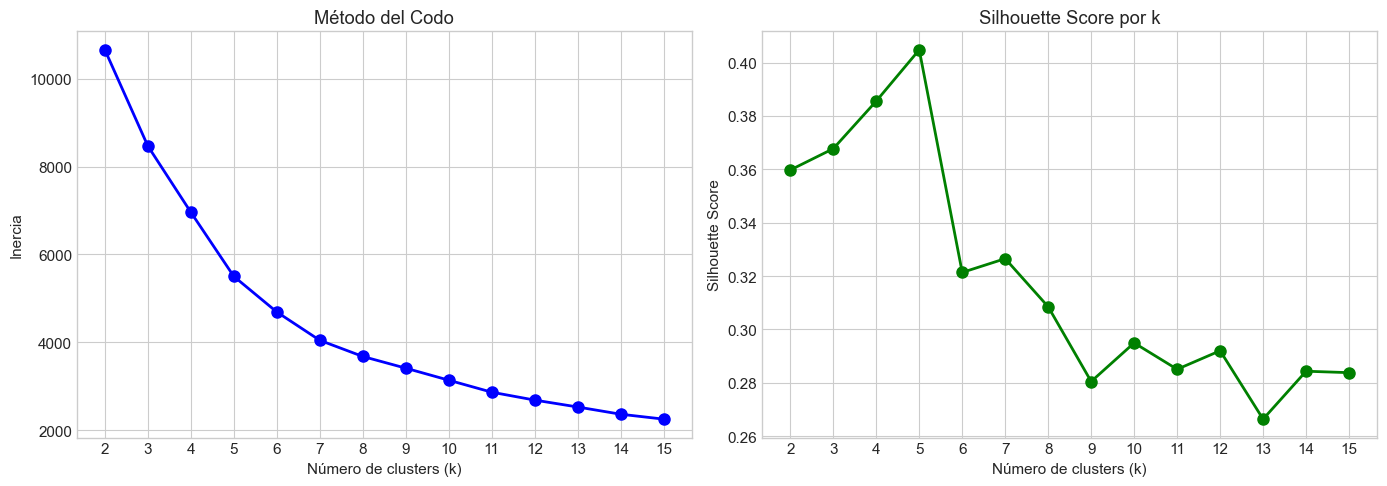


Mejor k según Silhouette Score: 5


In [10]:
# Visualizar método del codo y silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[0].set_xticks(list(k_range))

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

# Mejor k según silhouette
best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"\nMejor k según Silhouette Score: {best_k}")

## 7. Aplicar K-Means con k óptimo

Basándonos en el análisis anterior, seleccionamos el número de clusters.

In [11]:
# Seleccionar k (ajustar según resultados del gráfico)
# Típicamente entre 5-8 para balance entre granularidad y interpretabilidad
k_final = 5  # Ajustar según los gráficos

print(f"Número de clusters seleccionado: {k_final}")

# Entrenar modelo final
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
product_stats['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"\nDistribución de productos por cluster:")
print(product_stats['cluster'].value_counts().sort_index())

Número de clusters seleccionado: 5

Distribución de productos por cluster:
cluster
0    1601
1     948
2     119
3      93
4     288
Name: count, dtype: int64


## 8. Análisis y caracterización de clusters

In [12]:
# Estadísticas por cluster
cluster_profile = product_stats.groupby('cluster')[features_clustering].mean().round(2)
cluster_profile['n_products'] = product_stats.groupby('cluster').size()

print("Perfil de cada cluster (valores promedio):")
print(cluster_profile)

Perfil de cada cluster (valores promedio):
         mean_sales  cv_sales  pct_weeks_with_sales  mean_price  \
cluster                                                           
0              8.51      1.04                 74.94        4.44   
1              2.41      1.90                 36.49        4.60   
2              3.30      2.06                 38.70        6.27   
3             73.52      0.97                 84.68        1.79   
4              2.58      1.43                 53.30       15.94   

         seasonality_ratio  n_products  
cluster                                 
0                     1.48        1601  
1                     1.81         948  
2                     8.62         119  
3                     1.57          93  
4                     1.63         288  


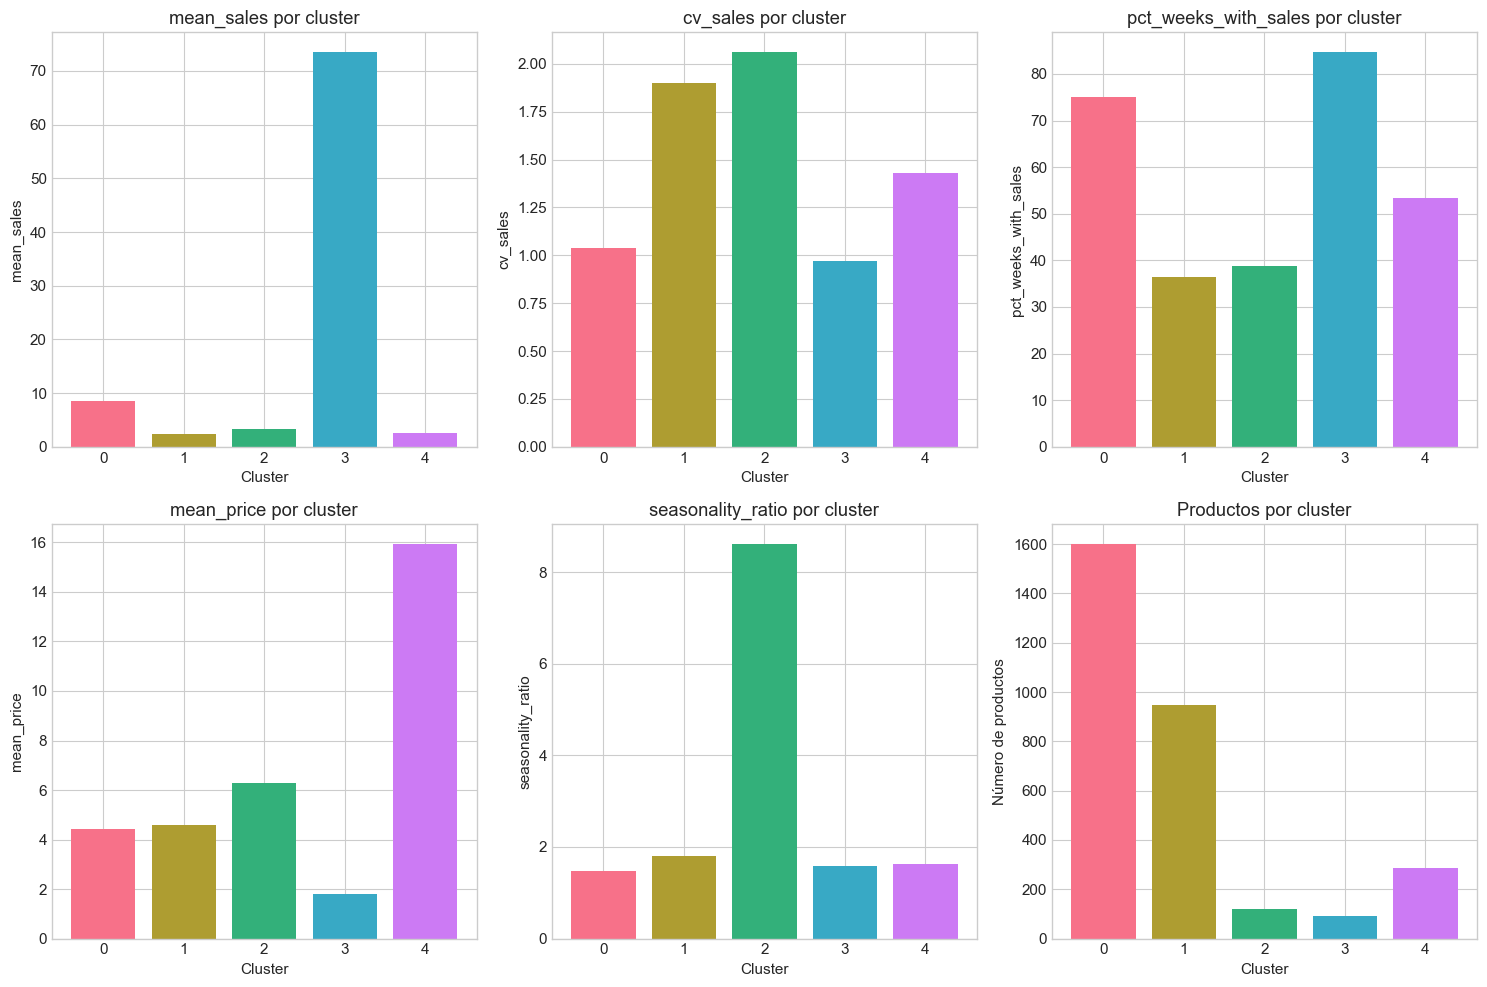

In [13]:
# Visualizar perfiles de clusters
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_clustering):
    ax = axes[idx]
    cluster_means = product_stats.groupby('cluster')[feature].mean()
    bars = ax.bar(cluster_means.index, cluster_means.values, color=sns.color_palette("husl", k_final))
    ax.set_xlabel('Cluster')
    ax.set_ylabel(feature)
    ax.set_title(f'{feature} por cluster')
    ax.set_xticks(range(k_final))

# Último subplot: distribución de productos
ax = axes[5]
counts = product_stats['cluster'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color=sns.color_palette("husl", k_final))
ax.set_xlabel('Cluster')
ax.set_ylabel('Número de productos')
ax.set_title('Productos por cluster')
ax.set_xticks(range(k_final))

plt.tight_layout()
plt.show()


Distribución de categorías por cluster (%):
category  ACCESORIES  HOME_&_GARDEN  SUPERMARKET
cluster                                         
0               14.2           33.0         52.8
1               21.9           33.6         44.4
2                4.2           44.5         51.3
3                1.1           17.2         81.7
4               43.1           45.5         11.5


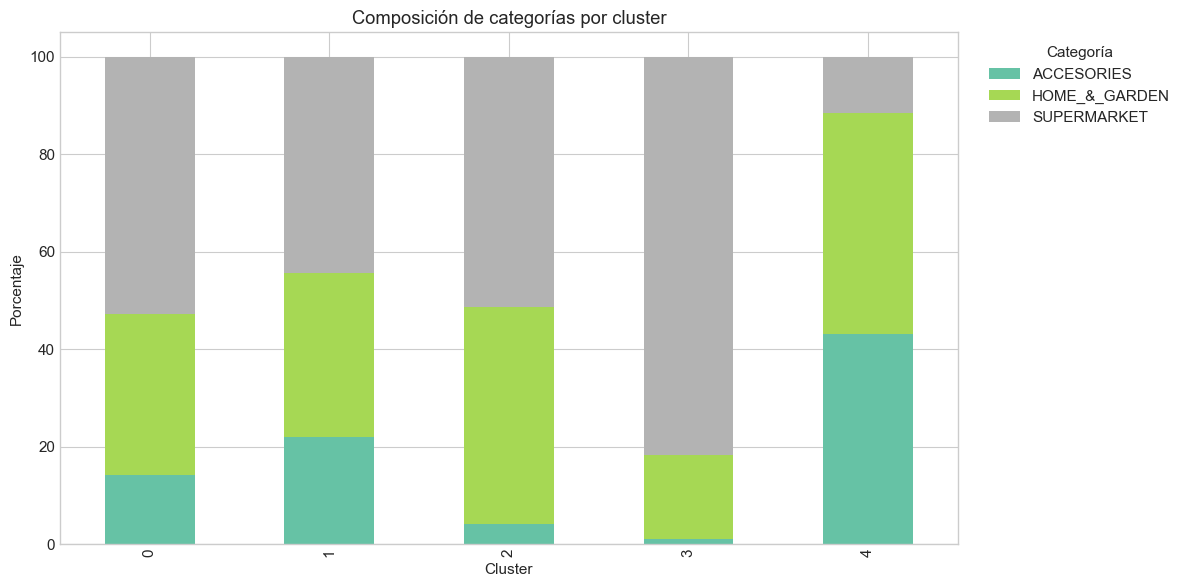

In [14]:
# Distribución de categorías por cluster
cat_by_cluster = pd.crosstab(product_stats['cluster'], product_stats['category'], normalize='index') * 100

print("\nDistribución de categorías por cluster (%):")
print(cat_by_cluster.round(1))

# Visualizar
cat_by_cluster.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.xlabel('Cluster')
plt.ylabel('Porcentaje')
plt.title('Composición de categorías por cluster')
plt.legend(title='Categoría', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [17]:
# Asignar nombres comerciales basados en los perfiles REALES
cluster_names = {
    0: 'Everyday Essentials',   # Alto volumen (8.5), estable (CV 1.04), alta frecuencia (75%), SUPERMARKET
    1: 'Sporadic Sellers',      # Bajo volumen (2.4), muy variable (CV 1.90), baja frecuencia (36%)
    2: 'Seasonal Spikes',       # Variable (CV 2.06), estacionalidad MUY ALTA (8.6x)
    3: 'Star Products',         # Volumen ALTÍSIMO (73.5), estable (CV 0.97), frecuencia alta (85%), precio bajo
    4: 'Premium Niche'          # Bajo volumen (2.6), precio ALTO ($15.94), HOME_&_GARDEN dominante
}

product_stats['cluster_name'] = product_stats['cluster'].map(cluster_names)

# Resumen con nombres corregidos
print("=" * 80)
print("CLUSTERS DE PRODUCTOS - RESUMEN EJECUTIVO (NOMBRES CORREGIDOS)")
print("=" * 80)

for cluster_id in sorted(product_stats['cluster'].unique()):
    name = cluster_names[cluster_id]
    cluster_data = product_stats[product_stats['cluster'] == cluster_id]
    n_products = len(cluster_data)
    avg_sales = cluster_data['mean_sales'].mean()
    cv = cluster_data['cv_sales'].mean()
    freq = cluster_data['pct_weeks_with_sales'].mean()
    price = cluster_data['mean_price'].mean()
    season = cluster_data['seasonality_ratio'].mean()
    
    cat_counts = cluster_data['category'].value_counts()
    cat_dominant = cat_counts.index[0]
    cat_pct = cat_counts.iloc[0] / n_products * 100
    
    print(f"\n🏷️  Cluster {cluster_id}: {name}")
    print(f"   Productos: {n_products} ({n_products/len(product_stats)*100:.1f}%)")
    print(f"   Ventas promedio: {avg_sales:.1f} unidades/semana")
    print(f"   Variabilidad (CV): {cv:.2f} {'(estable)' if cv < 1.2 else '(variable)' if cv < 1.8 else '(muy variable)'}")
    print(f"   Frecuencia: {freq:.0f}% semanas con ventas")
    print(f"   Precio medio: ${price:.2f}")
    print(f"   Estacionalidad: {season:.1f}x {'(baja)' if season < 2 else '(alta)' if season < 5 else '(muy alta)'}")
    print(f"   Categoría dominante: {cat_dominant} ({cat_pct:.0f}%)")

CLUSTERS DE PRODUCTOS - RESUMEN EJECUTIVO (NOMBRES CORREGIDOS)

🏷️  Cluster 0: Everyday Essentials
   Productos: 1601 (52.5%)
   Ventas promedio: 8.5 unidades/semana
   Variabilidad (CV): 1.04 (estable)
   Frecuencia: 75% semanas con ventas
   Precio medio: $4.44
   Estacionalidad: 1.5x (baja)
   Categoría dominante: SUPERMARKET (53%)

🏷️  Cluster 1: Sporadic Sellers
   Productos: 948 (31.1%)
   Ventas promedio: 2.4 unidades/semana
   Variabilidad (CV): 1.90 (muy variable)
   Frecuencia: 36% semanas con ventas
   Precio medio: $4.60
   Estacionalidad: 1.8x (baja)
   Categoría dominante: SUPERMARKET (44%)

🏷️  Cluster 2: Seasonal Spikes
   Productos: 119 (3.9%)
   Ventas promedio: 3.3 unidades/semana
   Variabilidad (CV): 2.06 (muy variable)
   Frecuencia: 39% semanas con ventas
   Precio medio: $6.27
   Estacionalidad: 8.6x (muy alta)
   Categoría dominante: SUPERMARKET (51%)

🏷️  Cluster 3: Star Products
   Productos: 93 (3.1%)
   Ventas promedio: 73.5 unidades/semana
   Variabilidad 

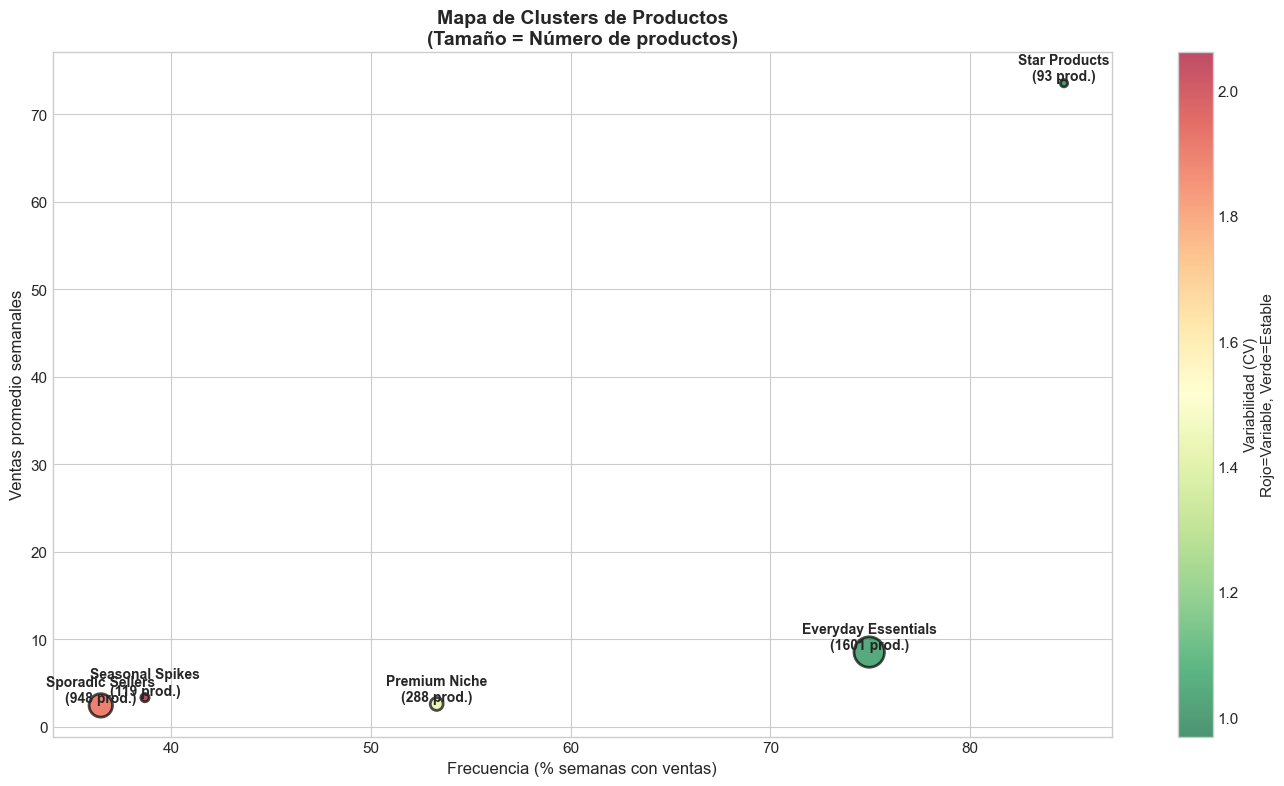

In [18]:
# Visualización resumen con nombres de clusters
fig, ax = plt.subplots(figsize=(14, 8))

# Datos para el gráfico
cluster_summary = product_stats.groupby('cluster').agg({
    'mean_sales': 'mean',
    'cv_sales': 'mean',
    'pct_weeks_with_sales': 'mean',
    'item': 'count'
}).rename(columns={'item': 'n_products'})

cluster_summary['cluster_name'] = cluster_summary.index.map(cluster_names)

# Bubble chart: x=frecuencia, y=ventas, tamaño=n_productos, color=variabilidad
scatter = ax.scatter(
    cluster_summary['pct_weeks_with_sales'],
    cluster_summary['mean_sales'],
    s=cluster_summary['n_products'] * 0.3,  # Tamaño proporcional a productos
    c=cluster_summary['cv_sales'],
    cmap='RdYlGn_r',  # Rojo=variable, Verde=estable
    alpha=0.7,
    edgecolors='black',
    linewidths=2
)

# Añadir etiquetas con nombres
for idx, row in cluster_summary.iterrows():
    ax.annotate(
        f"{row['cluster_name']}\n({row['n_products']:.0f} prod.)",
        (row['pct_weeks_with_sales'], row['mean_sales']),
        fontsize=10,
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.colorbar(scatter, label='Variabilidad (CV)\nRojo=Variable, Verde=Estable')
ax.set_xlabel('Frecuencia (% semanas con ventas)', fontsize=12)
ax.set_ylabel('Ventas promedio semanales', fontsize=12)
ax.set_title('Mapa de Clusters de Productos\n(Tamaño = Número de productos)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Descripción de Clusters para Marketing

### 🌟 **Star Products** (Cluster 3) - 93 productos (3%)
**Los campeones absolutos.** Productos de supermercado de bajo precio ($1.79) que venden 73 unidades/semana de forma muy consistente. Son el motor del negocio.
> **Acción Marketing:** Proteger disponibilidad al 100%, ubicación premium, nunca quedarse sin stock.

### 🏠 **Everyday Essentials** (Cluster 0) - 1,601 productos (52%)
**La columna vertebral del catálogo.** Más de la mitad del surtido. Ventas estables y frecuentes (75% de semanas). Principalmente supermercado.
> **Acción Marketing:** Programas de fidelización, promociones de volumen, cross-selling.

### 💎 **Premium Niche** (Cluster 4) - 288 productos (9%)
**Alto precio, clientes específicos.** Precio medio de $16 (3x el promedio). Dominado por HOME_&_GARDEN. Nicho rentable.
> **Acción Marketing:** Campañas de imagen, no competir en precio, destacar calidad y exclusividad.

### 🎲 **Sporadic Sellers** (Cluster 1) - 948 productos (31%)
**Impredecibles.** Alta variabilidad (CV 1.9), baja frecuencia (36%). Difíciles de predecir.
> **Acción Marketing:** Evaluar rentabilidad, considerar promociones para aumentar rotación o descatalogar.

### 🎄 **Seasonal Spikes** (Cluster 2) - 119 productos (4%)
**Los reyes de las temporadas.** Ventas que varían 8.6x entre temporada alta y baja. Muy sensibles al calendario.
> **Acción Marketing:** Campañas intensivas en temporada, stock cero fuera de temporada, planificación anticipada.

## 9. Visualización con PCA

Reducimos las features a 2 dimensiones para visualizar los clusters.

Varianza explicada por PC1: 45.7%
Varianza explicada por PC2: 21.9%
Varianza total explicada: 67.7%


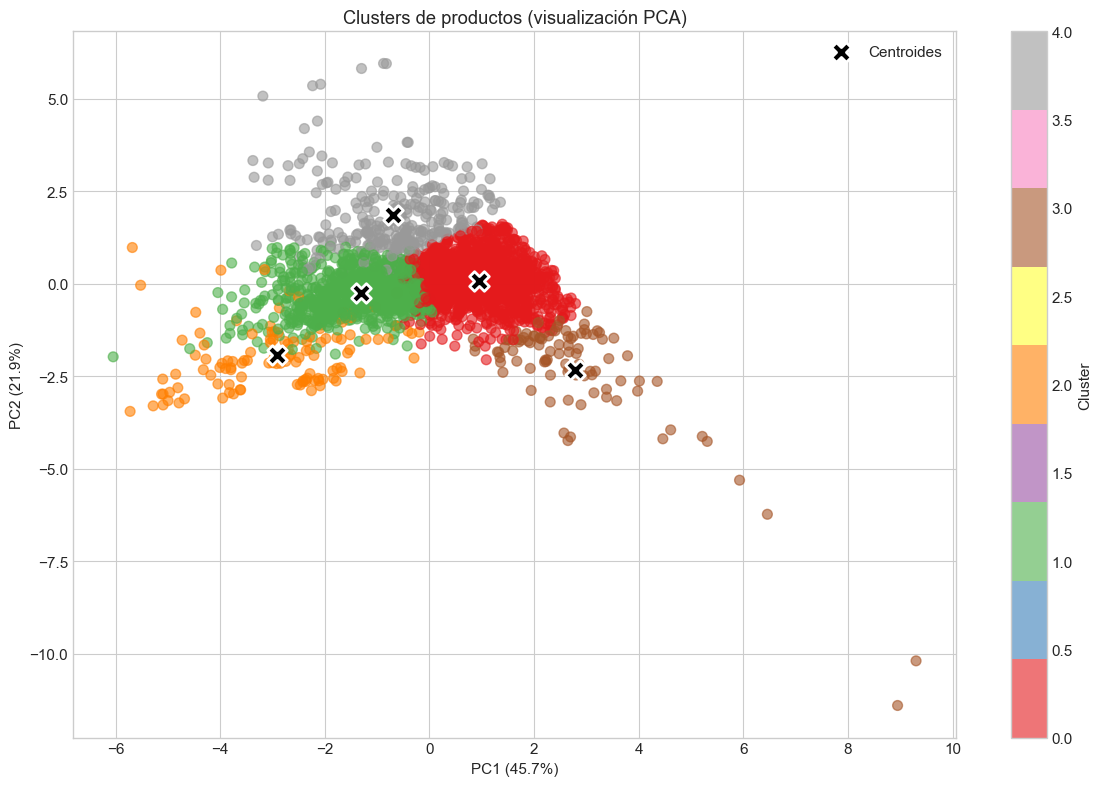

In [19]:
# Reducir a 2 dimensiones con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza explicada por PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Varianza explicada por PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Visualizar
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=product_stats['cluster'], 
                      cmap='Set1', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Clusters de productos (visualización PCA)')

# Añadir centroides
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', 
            s=200, edgecolors='white', linewidths=2, label='Centroides')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Clustering de tiendas (respuesta a Joelle)

Repetimos el proceso para agrupar las 10 tiendas según su comportamiento.

In [20]:
# Agregar ventas a nivel tienda
store_stats = df.groupby('store').agg({
    'sales': ['sum', 'mean', 'std'],
    'sell_price': 'mean',
    'region': 'first',
    'store_code': 'first'
}).reset_index()

store_stats.columns = ['store', 'total_sales', 'mean_sales', 'std_sales', 
                       'mean_price', 'region', 'store_code']

# Coeficiente de variación
store_stats['cv_sales'] = store_stats['std_sales'] / store_stats['mean_sales']

# Ventas por temporada
for season in seasons:
    season_col = f'season_{season}'
    if season_col in df.columns:
        season_sales = df[df[season_col] == 1].groupby('store')['sales'].mean()
        store_stats = store_stats.merge(
            season_sales.reset_index().rename(columns={'sales': f'mean_sales_{season}'}),
            on='store',
            how='left'
        )

print(f"Tiendas: {len(store_stats)}")
store_stats

Tiendas: 10


,store,total_sales,mean_sales,std_sales,mean_price,region,store_code,cv_sales,mean_sales_Winter_Holidays,mean_sales_Spring_Break,mean_sales_Summer_Vacation,mean_sales_Back_to_School,mean_sales_Regular
0,Back_Bay,6089330,7.262387,23.642289,5.550270,Boston,BOS_3,3.255443,6.659528,7.419902,7.699738,7.693276,7.096166
1,Brooklyn,4103676,4.894214,11.196881,5.577712,New York,NYC_4,2.287779,4.568317,4.975107,5.046726,5.034984,4.858609
2,Greenwich_Village,7698216,9.181211,24.362063,5.578080,New York,NYC_1,2.653469,8.551033,9.277199,9.762330,9.646055,8.992436
3,Harlem,5685475,6.780733,15.610719,5.573703,New York,NYC_2,2.302217,6.446584,6.853605,7.030389,7.205845,6.626186
4,Midtown_Village,5149062,6.140985,13.910867,5.588597,Philadelphia,PHI_1,2.265250,6.352367,6.382563,6.281209,5.968500,6.044175
5,Queen_Village,6427782,7.666039,25.086004,5.583868,Philadelphia,PHI_3,3.272355,7.080682,8.028711,7.801328,7.643672,7.666766
6,Roxbury,7214384,8.604173,27.405252,5.527348,Boston,BOS_2,3.185112,7.898907,8.753118,9.119701,9.067097,8.433791
7,South_End,5595292,6.673177,20.050180,5.534234,Boston,BOS_1,3.004593,6.185175,6.872005,7.124416,6.987872,6.504842
8,Tribeca,11188180,13.343487,38.960104,5.548703,New York,NYC_3,2.919784,11.881830,13.457435,14.316589,14.303866,13.072551
9,Yorktown,6544012,7.804660,22.786595,5.603906,Philadelphia,PHI_2,2.919614,7.264458,8.104650,8.106275,8.016873,7.690746


In [21]:
# Features para clustering de tiendas
features_stores = ['mean_sales', 'cv_sales', 'mean_price']

X_stores = store_stats[features_stores].fillna(0)
X_stores_scaled = StandardScaler().fit_transform(X_stores)

# Con solo 10 tiendas, probamos 2-5 clusters
k_range_stores = range(2, 6)
silhouette_stores = []

for k in k_range_stores:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_stores_scaled)
    score = silhouette_score(X_stores_scaled, labels)
    silhouette_stores.append(score)
    print(f"k={k}: Silhouette={score:.3f}")

best_k_stores = list(k_range_stores)[np.argmax(silhouette_stores)]
print(f"\nMejor k para tiendas: {best_k_stores}")

k=2: Silhouette=0.352
k=3: Silhouette=0.353
k=4: Silhouette=0.432
k=5: Silhouette=0.368

Mejor k para tiendas: 4


In [22]:
# Aplicar clustering a tiendas
kmeans_stores = KMeans(n_clusters=best_k_stores, random_state=42, n_init=10)
store_stats['cluster'] = kmeans_stores.fit_predict(X_stores_scaled)

print("Clusters de tiendas:")
print(store_stats[['store', 'region', 'total_sales', 'mean_sales', 'cv_sales', 'cluster']].sort_values('cluster'))

Clusters de tiendas:
               store        region  total_sales  mean_sales  cv_sales  cluster
0           Back_Bay        Boston      6089330    7.262387  3.255443        0
6            Roxbury        Boston      7214384    8.604173  3.185112        0
7          South_End        Boston      5595292    6.673177  3.004593        0
2  Greenwich_Village      New York      7698216    9.181211  2.653469        1
5      Queen_Village  Philadelphia      6427782    7.666039  3.272355        1
9           Yorktown  Philadelphia      6544012    7.804660  2.919614        1
1           Brooklyn      New York      4103676    4.894214  2.287779        2
3             Harlem      New York      5685475    6.780733  2.302217        2
4    Midtown_Village  Philadelphia      5149062    6.140985  2.265250        2
8            Tribeca      New York     11188180   13.343487  2.919784        3


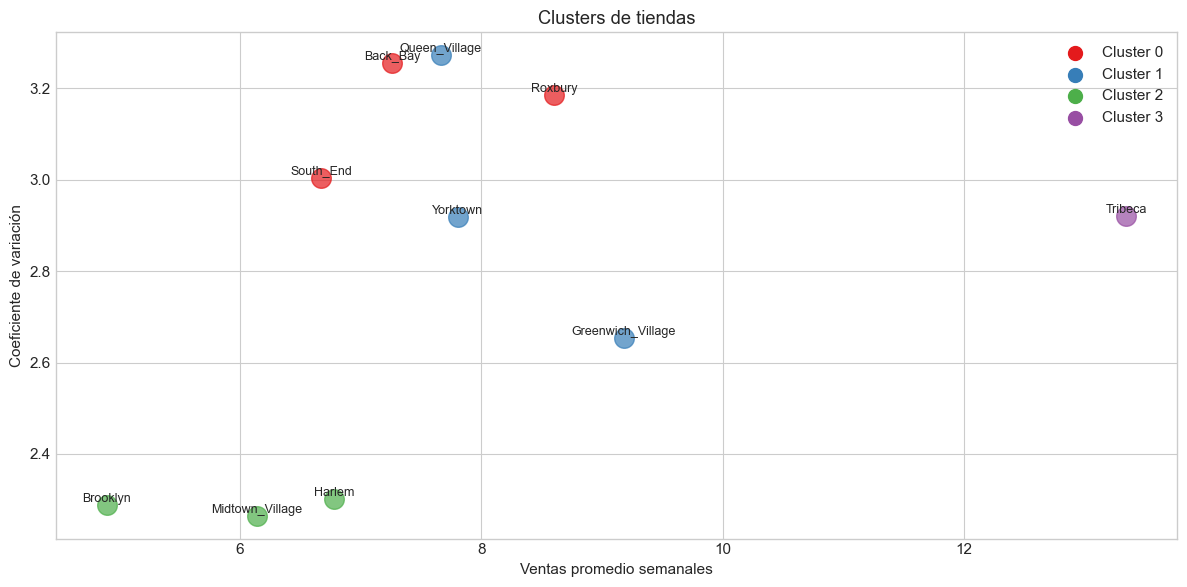

In [23]:
# Visualizar tiendas por cluster
fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette("Set1", best_k_stores)
for idx, row in store_stats.iterrows():
    ax.scatter(row['mean_sales'], row['cv_sales'], 
               c=[colors[row['cluster']]], s=200, alpha=0.7)
    ax.annotate(row['store'], (row['mean_sales'], row['cv_sales']), 
                fontsize=9, ha='center', va='bottom')

ax.set_xlabel('Ventas promedio semanales')
ax.set_ylabel('Coeficiente de variación')
ax.set_title('Clusters de tiendas')

# Leyenda manual
for i in range(best_k_stores):
    ax.scatter([], [], c=[colors[i]], s=100, label=f'Cluster {i}')
ax.legend()

plt.tight_layout()
plt.show()

In [24]:
# Guardar productos con su cluster asignado
output_products = product_stats[['item', 'category', 'department', 'cluster', 
                                  'total_sales', 'mean_sales', 'cv_sales', 
                                  'pct_weeks_with_sales', 'mean_price']]

output_path_products = '/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/products_clustered.csv'
output_products.to_csv(output_path_products, index=False)
print(f"✓ Productos con clusters guardados en: {output_path_products}")

# Guardar tiendas con su cluster asignado
output_stores = store_stats[['store', 'store_code', 'region', 'cluster', 
                              'total_sales', 'mean_sales', 'cv_sales']]

output_path_stores = '/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/stores_clustered.csv'
output_stores.to_csv(output_path_stores, index=False)
print(f"✓ Tiendas con clusters guardadas en: {output_path_stores}")

✓ Productos con clusters guardados en: /Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/products_clustered.csv
✓ Tiendas con clusters guardadas en: /Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/stores_clustered.csv
